Credit Card Dataset Shape: (284807, 31)
Missing Values: 0
Duplicate Rows: 1081
Legitimate Transactions: 99.8333%
Fraudulent Transactions: 0.1667%


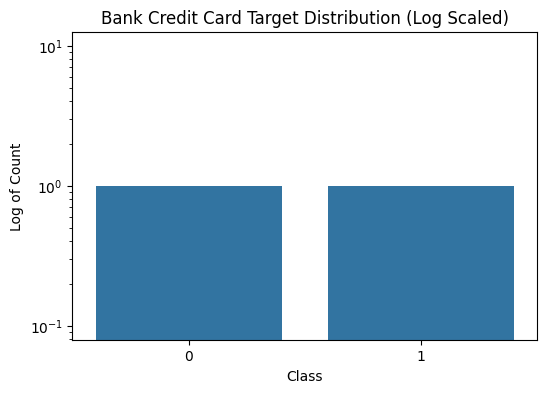

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cc_df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Credit Card Dataset Shape: {cc_df.shape}")
print(f"Missing Values: {cc_df.isnull().sum().sum()}")
print(f"Duplicate Rows: {cc_df.duplicated().sum()}")

# Drop duplicate transactions to avoid testing leaks
cc_df = cc_df.drop_duplicates()

# Quantify extreme class imbalance
cc_imbalance = cc_df['Class'].value_counts(normalize=True) * 100
print(f"Legitimate Transactions: {cc_imbalance[0]:.4f}%")
print(f"Fraudulent Transactions: {cc_imbalance[1]:.4f}%")

# Plotting the extreme distribution gap
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=cc_df, log=True)
plt.title('Bank Credit Card Target Distribution (Log Scaled)')
plt.ylabel('Log of Count')
plt.show()

In [3]:
cc_df.to_csv('../data/processed/creditcard_cleaned.csv', index=False)